In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("MoviesOnStreamingPlatforms.csv")

In [8]:
df.head()

,Unnamed: 0,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
0,0,1,The Irishman,2019,18+,98/100,1,0,0,0,0
1,1,2,Dangal,2016,7+,97/100,1,0,0,0,0
2,2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,0
3,3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,0
4,4,5,Roma,2018,18+,94/100,1,0,0,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9515 entries, 0 to 9514
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       9515 non-null   int64 
 1   ID               9515 non-null   int64 
 2   Title            9515 non-null   object
 3   Year             9515 non-null   int64 
 4   Age              5338 non-null   object
 5   Rotten Tomatoes  9508 non-null   object
 6   Netflix          9515 non-null   int64 
 7   Hulu             9515 non-null   int64 
 8   Prime Video      9515 non-null   int64 
 9   Disney+          9515 non-null   int64 
 10  Type             9515 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 817.8+ KB


In [10]:
df = df.drop_duplicates()
df = df.dropna()

In [12]:
df['Rotten Tomatoes'] = df['Rotten Tomatoes'].str.extract('(\d+)')
df['Rotten Tomatoes'] = pd.to_numeric(df['Rotten Tomatoes'])

In [13]:
df['target'] = df['Rotten Tomatoes'].apply(lambda x: 1 if x >= 70 else 0)

In [14]:
X = df[['Year','Netflix','Hulu','Prime Video','Disney+']]
y = df['target']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7855805243445693


In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[823  31]
 [198  16]]


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression

lr_fixed = LogisticRegression(max_iter=1000)
lr_fixed.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
from sklearn.metrics import accuracy_score

y_pred_lr = lr_fixed.predict(X_test_scaled)
print("Fixed LR Accuracy:", accuracy_score(y_test, y_pred_lr))

Fixed LR Accuracy: 0.7949438202247191


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[823  31]
 [198  16]]


In [28]:
print("Random Forest:", accuracy_score(y_test, y_pred))
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))

Random Forest: 0.7855805243445693
Logistic Regression: 0.7949438202247191


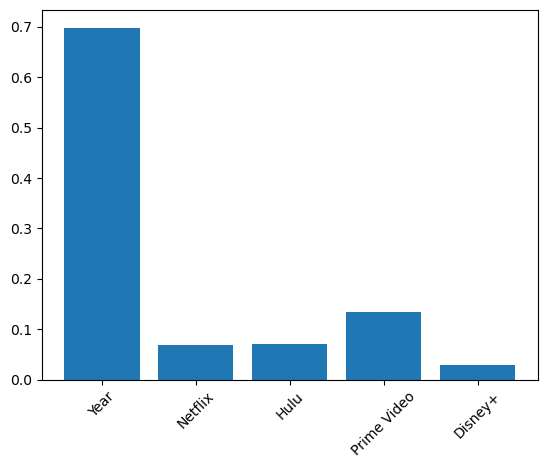

In [31]:
import matplotlib.pyplot as plt

plt.bar(X.columns, model.feature_importances_)
plt.xticks(rotation=45)
plt.show()

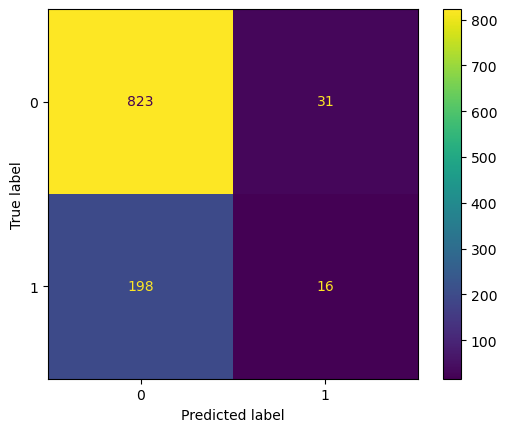

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [36]:
import pandas as pd

sample = pd.DataFrame([[2020,1,0,1,0]], 
                      columns=['Year','Netflix','Hulu','Prime Video','Disney+'])

print("Prediction:", model.predict(sample))

Prediction: [0]
